In [1]:
!pip install scipy scikit-learn matplotlib pandas liac-arff

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11782 sha256=96b492cbf94d04bbae64ee005a5795a9a0098fa2de4320b6a10b184f34930c8e
  Stored in directory: c:\users\radhe\appdata\local\pip\cache\wheels\93\f3\5b\658a9bddee916a5f4b84bdc1a4e0fabd22fb17947c2c9542e6
Successfully built liac-arff


  DEPRECATION: Building 'liac-arff' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'liac-arff'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


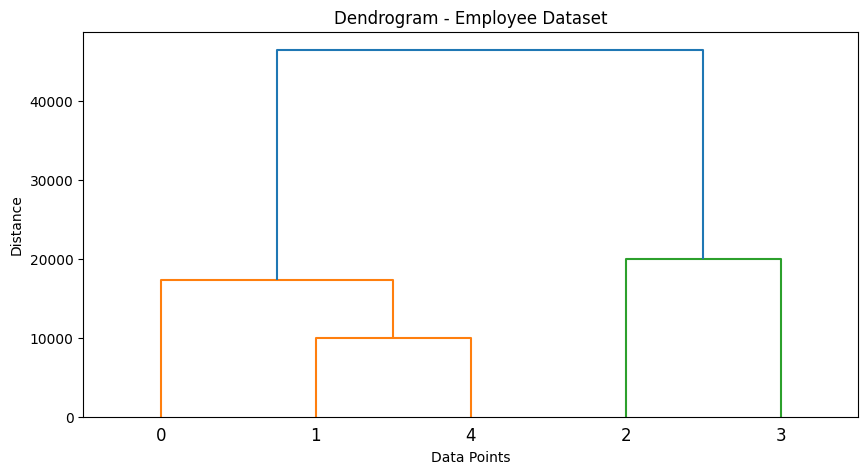

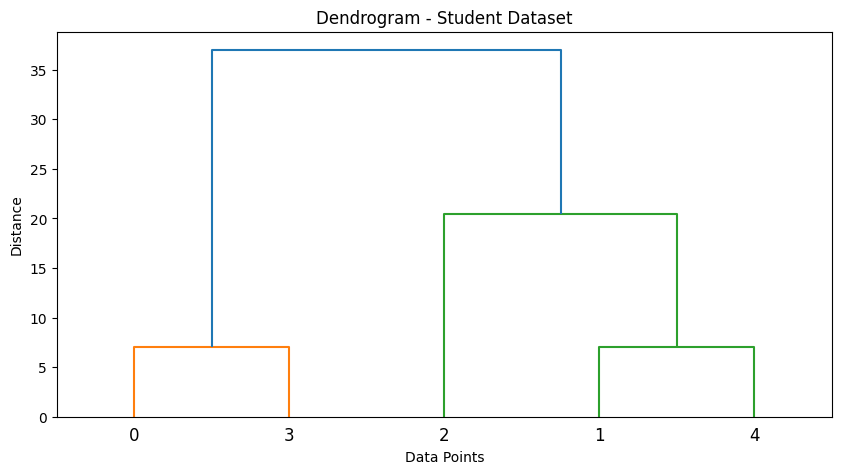

In [3]:
import arff
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load ARFF file
def load_arff(file_path):
    with open(file_path, 'r') as f:
        dataset = arff.load(f)
    df = pd.DataFrame(dataset['data'])
    df.columns = [attr[0] for attr in dataset['attributes']]
    return df

# Preprocess data (convert categorical to numeric)
def preprocess(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
    return df

# Hierarchical clustering function
def hierarchical_clustering(df, title):
    linked = linkage(df, method='ward')

    plt.figure(figsize=(10, 5))
    dendrogram(linked)
    plt.title(f"Dendrogram - {title}")
    plt.xlabel("Data Points")
    plt.ylabel("Distance")
    plt.show()

# Load datasets
employee_df = load_arff("employee.arff")
student_df = load_arff("student.arff")

# Preprocess
employee_df = preprocess(employee_df)
student_df = preprocess(student_df)

# Apply clustering
hierarchical_clustering(employee_df, "Employee Dataset")
hierarchical_clustering(student_df, "Student Dataset")